# 07_analyze_test_cases.ipynb

Анализ поведения CNN-baseline на `test`:

- загрузка baseline checkpoint;
- восстановление `ds_test` в том же residual-режиме;
- пересчёт метрик на test;
- сортировка по ошибке;
- визуализация **worst / median / best** примеров;
- гистограмма RMSE;
- сравнение простых статистик target-карт для лучших и худших случаев.

## 0. Важно про JAX
Эта ячейка должна выполняться **до любого `import jax`**.

Если в текущем kernel JAX уже импортировался, лучше перезапустить kernel и начать с начала.

In [1]:
import os

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = ".50"
os.environ.pop("LD_LIBRARY_PATH", None)

'/usr/local/cuda/lib64'

In [2]:
from pathlib import Path
import json
import random

import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("device name:", torch.cuda.get_device_name(0))

torch: 2.10.0+cu128
cuda available: True
device name: NVIDIA GeForce RTX 5090


In [3]:
OUT_ROOT = Path("/workspace/usct_dataset_v2")
TEST_DIR = OUT_ROOT / "test"
assert TEST_DIR.exists(), TEST_DIR

test_files = sorted(TEST_DIR.glob("*.npz"))
print("test files:", len(test_files))
assert len(test_files) > 0

CKPT_PATH = Path("/workspace/reference_points/baseline_residual_v2_main/baseline_model.pt")
assert CKPT_PATH.exists(), CKPT_PATH
print("checkpoint:", CKPT_PATH)

test files: 800
checkpoint: /workspace/reference_points/baseline_residual_v2_main/baseline_model.pt


In [4]:
ckpt = torch.load(CKPT_PATH, map_location="cpu")
stats = ckpt["stats"]
experiment_config = ckpt.get("experiment_config", {})
print("stats:", stats)
print("experiment_config:")
print(json.dumps(experiment_config, ensure_ascii=False, indent=2))

stats: {'c_min': 1404.1473388671875, 'c_max': 1598.34423828125, 'x_scale_min': 290344.0, 'x_scale_max': 321105.0625, 'x_scale_mean': 296926.66734879033}
experiment_config:
{
  "run_name": "baseline_residual_v2_main",
  "seed": 42,
  "model_name": "SimpleUSCTBaseline",
  "input_type": "residual",
  "input_formula": "M_res = M - M_hom",
  "mask_self_receivers": true,
  "mask_half_width": 2,
  "target": "speed_map",
  "target_shape": [
    192,
    192
  ],
  "input_shape": [
    2,
    16,
    256
  ],
  "num_train_examples": 6200,
  "num_val_examples": 1000,
  "num_test_examples": 800,
  "best_epoch": 297,
  "best_val_loss_norm_mse": 0.0011710899574682116,
  "c_min": 1404.1473388671875,
  "c_max": 1598.34423828125
}


In [5]:
sample0 = np.load(test_files[0])

S, R = sample0["x"].shape[1], sample0["x"].shape[2]
H, W = sample0["c"].shape
dx = tuple(sample0["dx"].astype(np.float32))
freq_hz = float(sample0["freq_hz"][0])

CFG = {
    "H": H,
    "W": W,
    "freq_hz": freq_hz,
    "density": 1000.0,
    "pml_size": 16,
    "num_sources": int(S),
    "num_receivers": int(R),
    "source_sigma_px": 1.8,
}

receiver_y = sample0["receiver_y"].astype(np.int64)
receiver_x = sample0["receiver_x"].astype(np.int64)
source_ring_idx = sample0["source_ring_idx"].astype(np.int64)

print("CFG:", CFG)
print("dx:", dx)

CFG: {'H': 192, 'W': 192, 'freq_hz': 500000.0, 'density': 1000.0, 'pml_size': 16, 'num_sources': 16, 'num_receivers': 256, 'source_sigma_px': 1.8}
dx: (np.float32(0.00075), np.float32(0.00075))


In [6]:
import jax
import jax.numpy as jnp
from jax import jit

from jwave import FourierSeries
from jwave.geometry import Domain, Medium
from jwave.acoustics.time_harmonic import helmholtz_solver

print("jax version:", jax.__version__)
print("jax devices:", jax.devices())

jax version: 0.4.38
jax devices: [CudaDevice(id=0)]


In [7]:
def gaussian_source(H: int, W: int, y0: int, x0: int, sigma: float = 1.8):
    yy, xx = np.mgrid[0:H, 0:W]
    g = np.exp(-((yy - y0) ** 2 + (xx - x0) ** 2) / (2 * sigma**2))
    g = g / g.sum()
    return g.astype(np.float32)

@jit
def solve_helmholtz_jit(medium, omega, src):
    return helmholtz_solver(medium, omega, src)

def simulate_measurement_matrix_from_geometry(c_map, receiver_y, receiver_x, source_ring_idx, dx, cfg):
    H, W = c_map.shape
    domain = Domain((H, W), dx)
    sound_speed = FourierSeries(jnp.expand_dims(jnp.array(c_map), -1), domain)
    medium = Medium(
        domain=domain,
        sound_speed=sound_speed,
        density=cfg["density"],
        pml_size=cfg["pml_size"],
    )

    omega = 2 * np.pi * cfg["freq_hz"]
    M = np.zeros((len(source_ring_idx), len(receiver_y)), dtype=np.complex64)

    for i, ridx in enumerate(source_ring_idx):
        y0 = int(receiver_y[ridx])
        x0 = int(receiver_x[ridx])

        src_np = gaussian_source(H, W, y0, x0, sigma=cfg["source_sigma_px"])
        src_field = jnp.array(src_np, dtype=jnp.complex64)
        src = FourierSeries(jnp.expand_dims(src_field, -1), domain)

        field = solve_helmholtz_jit(medium, omega, src * omega)
        u = np.array(field.params[..., 0])
        M[i] = u[receiver_y, receiver_x]

    return M

In [8]:
c_hom = np.full((H, W), 1500.0, dtype=np.float32)

M_hom_complex = simulate_measurement_matrix_from_geometry(
    c_hom,
    receiver_y=receiver_y,
    receiver_x=receiver_x,
    source_ring_idx=source_ring_idx,
    dx=dx,
    cfg=CFG,
)

print("M_hom_complex:", M_hom_complex.shape, M_hom_complex.dtype)

/tmp/ipykernel_2110/2885456303.py:13: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  domain = Domain((H, W), dx)


M_hom_complex: (16, 256) complex64


In [9]:
def mask_self_receivers(M: np.ndarray, source_ring_idx: np.ndarray, half_width: int = 2) -> np.ndarray:
    M = M.copy()
    S, R = M.shape

    if len(source_ring_idx) != S:
        raise ValueError(f"source_ring_idx length {len(source_ring_idx)} != number of sources {S}")

    for s in range(S):
        ridx = int(source_ring_idx[s])
        for delta in range(-half_width, half_width + 1):
            rr = (ridx + delta) % R
            M[s, rr] = 0.0 + 0.0j

    return M

class USCTPairDataset(Dataset):
    def __init__(self, paths, c_min, c_max, M_hom_complex, use_residual=True, mask_half_width=2):
        self.paths = list(paths)
        self.c_min = float(c_min)
        self.c_max = float(c_max)
        self.c_range = max(self.c_max - self.c_min, 1e-8)
        self.M_hom_complex = M_hom_complex
        self.use_residual = bool(use_residual)
        self.mask_half_width = int(mask_half_width)

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        d = np.load(self.paths[idx])
        x_raw = d["x"].astype(np.float32)
        c = d["c"].astype(np.float32)
        source_ring_idx = d["source_ring_idx"].astype(np.int64)

        M = x_raw[0] + 1j * x_raw[1]
        if self.use_residual:
            M = M - self.M_hom_complex
        if self.mask_half_width > 0:
            M = mask_self_receivers(M, source_ring_idx, half_width=self.mask_half_width)

        x = np.stack([M.real, M.imag], axis=0).astype(np.float32)

        x_scale = float(np.percentile(np.abs(x), 99.5))
        if x_scale < 1e-8:
            x_scale = 1.0
        x = x / x_scale

        c = (c - self.c_min) / self.c_range

        x = torch.from_numpy(x)
        c = torch.from_numpy(c).unsqueeze(0)
        meta = {"path": str(self.paths[idx]), "x_scale": x_scale}
        return x, c, meta

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=stride, padding=1),
            nn.GroupNorm(1, out_ch),
            nn.GELU(),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, stride=1, padding=1),
            nn.GroupNorm(1, out_ch),
            nn.GELU(),
        )
    def forward(self, x):
        return self.block(x)

class SimpleUSCTBaseline(nn.Module):
    def __init__(self, in_ch=2):
        super().__init__()
        self.enc1 = ConvBlock(in_ch, 32, stride=1)
        self.enc2 = ConvBlock(32, 64, stride=2)
        self.enc3 = ConvBlock(64, 128, stride=2)
        self.enc4 = ConvBlock(128, 128, stride=2)
        self.flatten = nn.Flatten()
        self.fc = nn.Sequential(nn.Linear(128 * 2 * 32, 128 * 12 * 12), nn.GELU())
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(128, 128, kernel_size=4, stride=2, padding=1), nn.GELU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1), nn.GELU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1), nn.GELU(),
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1), nn.GELU(),
            nn.Conv2d(16, 1, kernel_size=3, padding=1),
            nn.Sigmoid(),
        )
    def forward(self, x):
        z = self.enc1(x)
        z = self.enc2(z)
        z = self.enc3(z)
        z = self.enc4(z)
        z = self.flatten(z)
        z = self.fc(z)
        z = z.view(x.shape[0], 128, 12, 12)
        return self.dec(z)

In [10]:
ds_test = USCTPairDataset(
    test_files,
    stats["c_min"],
    stats["c_max"],
    M_hom_complex=M_hom_complex,
    use_residual=True,
    mask_half_width=2,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleUSCTBaseline().to(device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

print("loaded model and test dataset")
print("test size:", len(ds_test))

loaded model and test dataset
test size: 800


In [11]:
def denorm_c(c_norm, c_min, c_max):
    return c_norm * (c_max - c_min) + c_min

def mse(a, b):
    return float(np.mean((a - b) ** 2))

def rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))

def relative_l2(a, b):
    num = np.linalg.norm(a - b)
    den = np.linalg.norm(b) + 1e-8
    return float(num / den)

def psnr_from_mse(mse_value, data_range):
    if mse_value <= 1e-12:
        return float("inf")
    return float(20 * np.log10(data_range) - 10 * np.log10(mse_value))

try:
    from skimage.metrics import structural_similarity as ssim_fn
    HAS_SKIMAGE = True
except Exception:
    HAS_SKIMAGE = False
    ssim_fn = None

def compute_metrics(pred, target, data_range):
    out = {
        "mse": mse(pred, target),
        "rmse": rmse(pred, target),
        "relative_l2": relative_l2(pred, target),
        "psnr": psnr_from_mse(mse(pred, target), data_range),
    }
    if HAS_SKIMAGE:
        out["ssim"] = float(ssim_fn(pred, target, data_range=data_range))
    return out

def target_stats(c_phys):
    return {
        "c_min": float(c_phys.min()),
        "c_max": float(c_phys.max()),
        "c_mean": float(c_phys.mean()),
        "c_std": float(c_phys.std()),
    }

def predict_one(model, dataset, idx, device, c_min, c_max):
    x, c, meta = dataset[idx]
    with torch.no_grad():
        pred = model(x.unsqueeze(0).to(device)).cpu()[0, 0].numpy()
    target = c[0].numpy()
    pred_phys = denorm_c(pred, c_min, c_max)
    target_phys = denorm_c(target, c_min, c_max)
    return {
        "idx": idx,
        "path": meta["path"],
        "pred_phys": pred_phys,
        "target_phys": target_phys,
        "error_abs": np.abs(pred_phys - target_phys),
        "target_stats": target_stats(target_phys),
    }

def evaluate_dataset(model, dataset, c_min, c_max, device):
    metrics_list = []
    data_range = float(c_max - c_min)
    for i in range(len(dataset)):
        out = predict_one(model, dataset, i, device, c_min, c_max)
        m = compute_metrics(out["pred_phys"], out["target_phys"], data_range=data_range)
        m["index"] = i
        m["path"] = out["path"]
        m.update(out["target_stats"])
        metrics_list.append(m)
    return metrics_list

In [12]:
test_metrics_list = evaluate_dataset(model, ds_test, stats["c_min"], stats["c_max"], device)

summary = {}
for key in test_metrics_list[0].keys():
    if key in ("index", "path"):
        continue
    vals = [row[key] for row in test_metrics_list]
    summary[f"{key}_mean"] = float(np.mean(vals))
    summary[f"{key}_std"] = float(np.std(vals))

print("TEST SUMMARY")
print(json.dumps(summary, ensure_ascii=False, indent=2))

TEST SUMMARY
{
  "mse_mean": 377.7047533416748,
  "mse_std": 194.93539764966624,
  "rmse_mean": 18.739840031862258,
  "rmse_std": 5.150063071225921,
  "relative_l2_mean": 0.012558973678969777,
  "relative_l2_std": 0.003448133352360726,
  "psnr_mean": 20.66702581355311,
  "psnr_std": 2.5563665325878406,
  "c_min_mean": 1433.7333361816407,
  "c_min_std": 11.936017273299361,
  "c_max_mean": 1556.5424217224122,
  "c_max_std": 11.632215674822055,
  "c_mean_mean": 1491.8999085998535,
  "c_mean_std": 5.427919979633257,
  "c_std_mean": 21.56676334261894,
  "c_std_std": 5.620791118076137
}


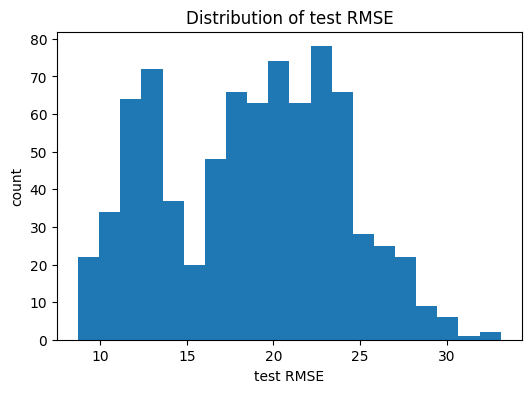

RMSE min/median/max: 8.715707778930664 19.158297538757324 33.13203430175781


In [13]:
rmses = [row["rmse"] for row in test_metrics_list]

plt.figure(figsize=(6, 4))
plt.hist(rmses, bins=20)
plt.xlabel("test RMSE")
plt.ylabel("count")
plt.title("Distribution of test RMSE")
plt.show()

print("RMSE min/median/max:", float(np.min(rmses)), float(np.median(rmses)), float(np.max(rmses)))

In [14]:
test_sorted = sorted(test_metrics_list, key=lambda x: x["rmse"], reverse=True)

print("Worst 10 test cases by RMSE:")
for row in test_sorted[:10]:
    print(
        f'idx={row["index"]:4d} | rmse={row["rmse"]:.4f} | rel_l2={row["relative_l2"]:.6f} | '
        f'c_std={row["c_std"]:.4f} | path={row["path"]}'
    )

Worst 10 test cases by RMSE:
idx= 109 | rmse=33.1320 | rel_l2=0.022087 | c_std=20.9161 | path=/workspace/usct_dataset_v2/test/sample_00109.npz
idx= 443 | rmse=33.1320 | rel_l2=0.022087 | c_std=20.9161 | path=/workspace/usct_dataset_v2/test/sample_00443.npz
idx= 380 | rmse=31.2831 | rel_l2=0.020934 | c_std=27.3569 | path=/workspace/usct_dataset_v2/test/sample_00380.npz
idx= 576 | rmse=30.4916 | rel_l2=0.020544 | c_std=28.5697 | path=/workspace/usct_dataset_v2/test/sample_00576.npz
idx=   6 | rmse=30.1147 | rel_l2=0.020273 | c_std=29.5498 | path=/workspace/usct_dataset_v2/test/sample_00006.npz
idx= 660 | rmse=29.8890 | rel_l2=0.019995 | c_std=26.3831 | path=/workspace/usct_dataset_v2/test/sample_00660.npz
idx= 366 | rmse=29.7644 | rel_l2=0.019917 | c_std=26.9860 | path=/workspace/usct_dataset_v2/test/sample_00366.npz
idx= 662 | rmse=29.6872 | rel_l2=0.019852 | c_std=25.9071 | path=/workspace/usct_dataset_v2/test/sample_00662.npz
idx= 422 | rmse=29.6502 | rel_l2=0.019761 | c_std=20.9006 |

In [15]:
N_SHOW = 5

worst_indices = [row["index"] for row in test_sorted[:N_SHOW]]
best_indices = [row["index"] for row in test_sorted[-N_SHOW:]]
median_slice = test_sorted[len(test_sorted)//2 - N_SHOW//2 : len(test_sorted)//2 - N_SHOW//2 + N_SHOW]
median_indices = [row["index"] for row in median_slice]

print("worst_indices:", worst_indices)
print("median_indices:", median_indices)
print("best_indices:", best_indices)

worst_indices: [109, 443, 380, 576, 6]
median_indices: [559, 264, 302, 788, 322]
best_indices: [600, 350, 630, 152, 609]


worst test example: 109


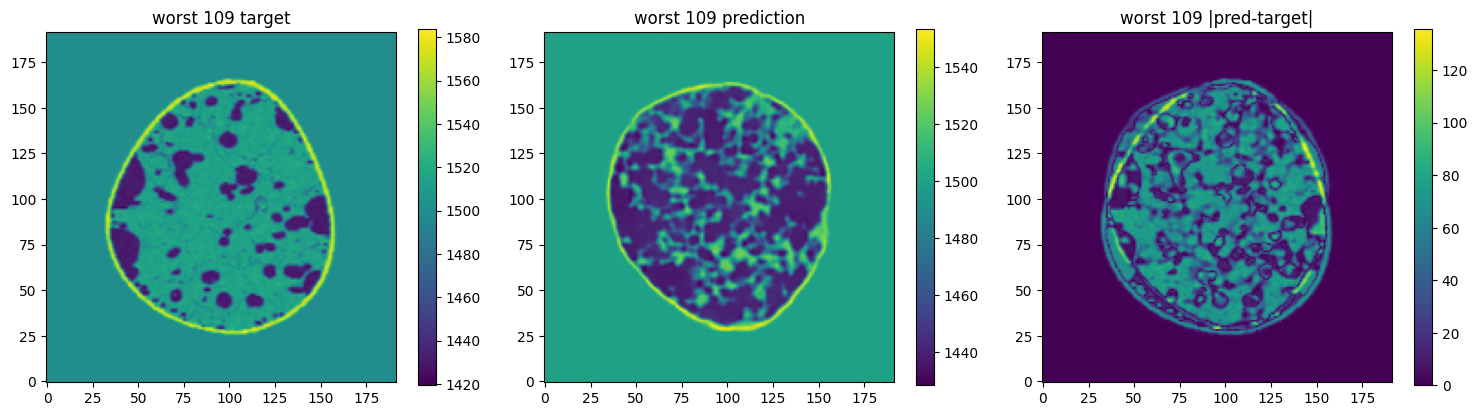

worst test example: 443


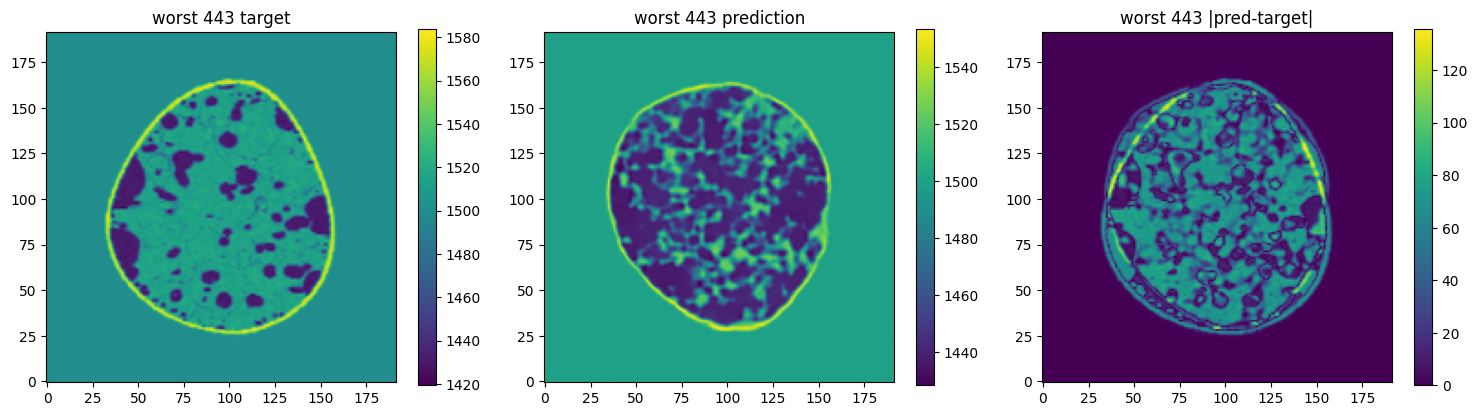

worst test example: 380


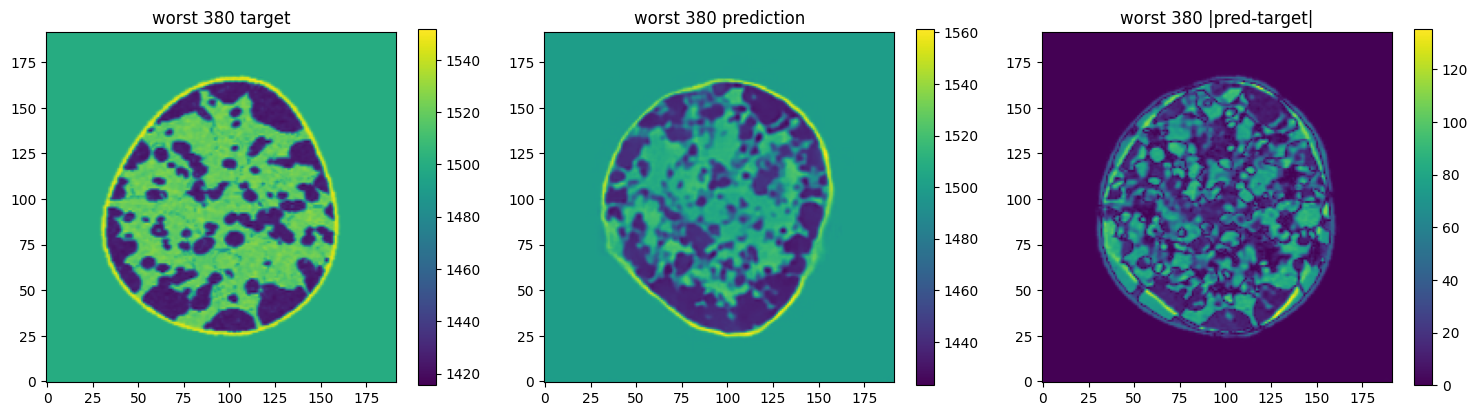

worst test example: 576


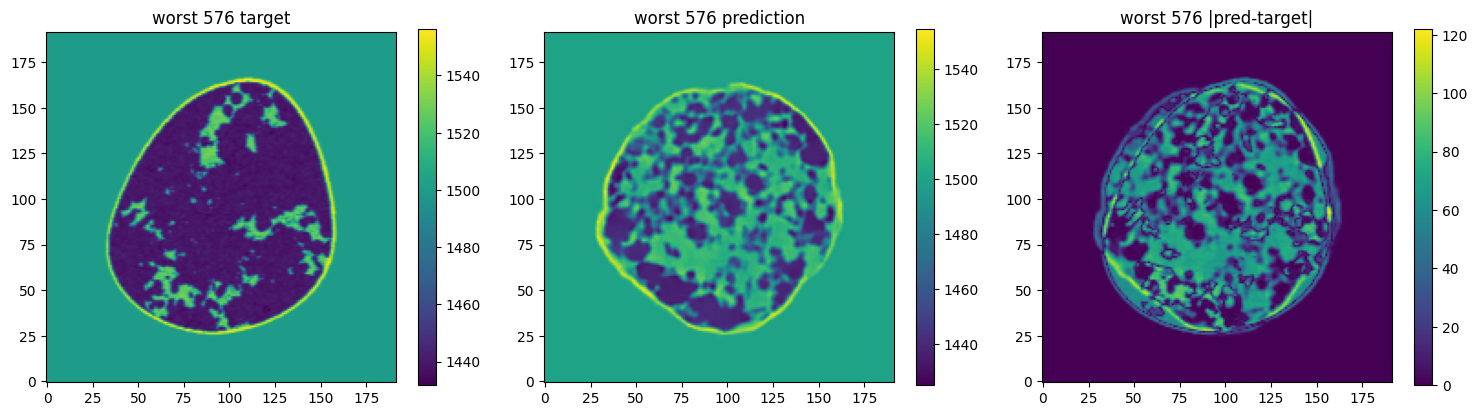

worst test example: 6


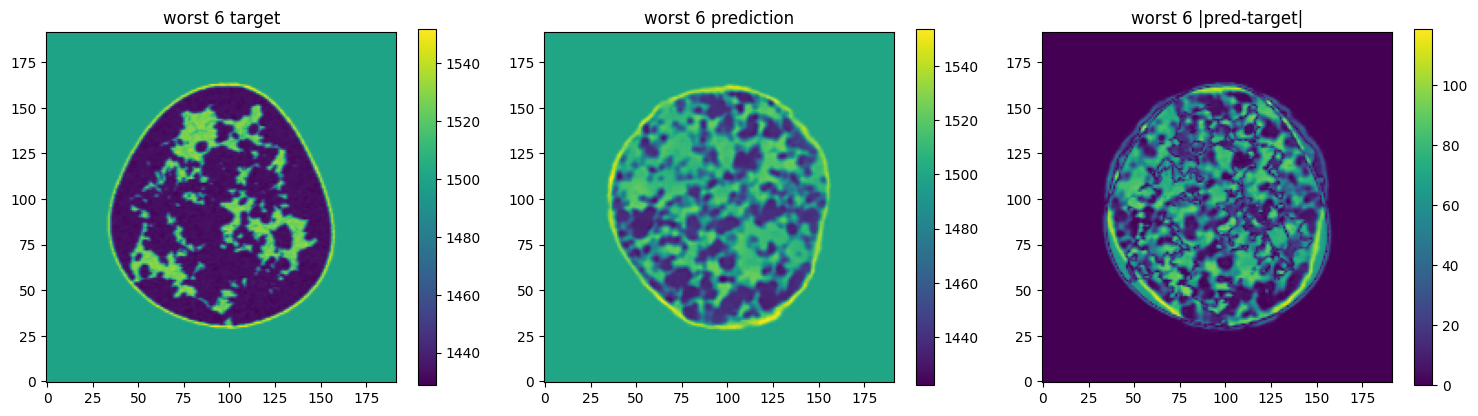

In [16]:
def show_prediction_case(model, dataset, idx, device, c_min, c_max, title_prefix=""):
    out = predict_one(model, dataset, idx, device, c_min, c_max)

    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    im0 = ax[0].imshow(out["target_phys"], origin="lower")
    ax[0].set_title(f"{title_prefix} target")
    plt.colorbar(im0, ax=ax[0])

    im1 = ax[1].imshow(out["pred_phys"], origin="lower")
    ax[1].set_title(f"{title_prefix} prediction")
    plt.colorbar(im1, ax=ax[1])

    im2 = ax[2].imshow(out["error_abs"], origin="lower")
    ax[2].set_title(f"{title_prefix} |pred-target|")
    plt.colorbar(im2, ax=ax[2])

    plt.tight_layout()
    plt.show()

for idx in worst_indices:
    print("worst test example:", idx)
    show_prediction_case(model, ds_test, idx, device, stats["c_min"], stats["c_max"], title_prefix=f"worst {idx}")

median test example: 559


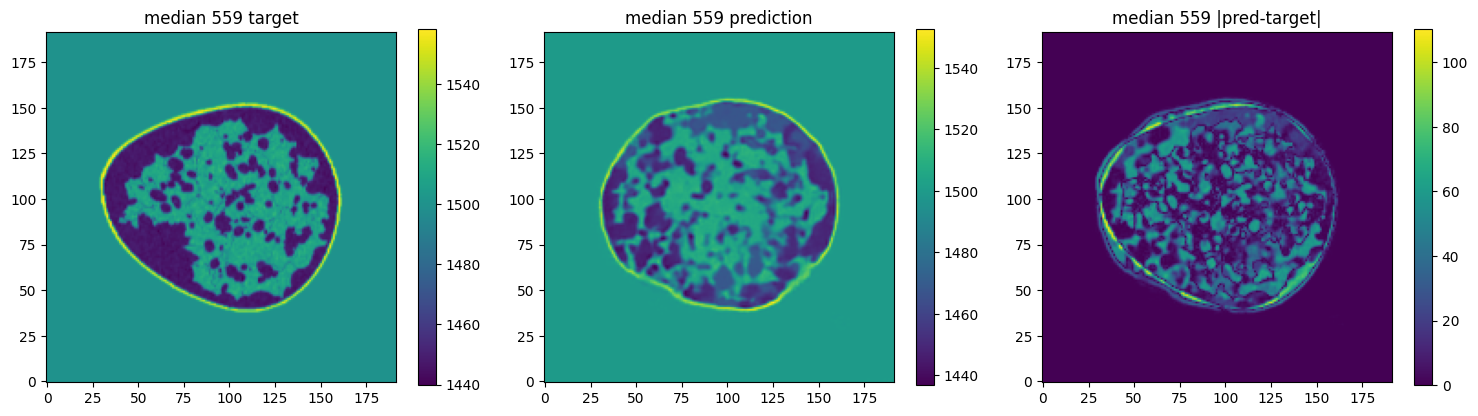

median test example: 264


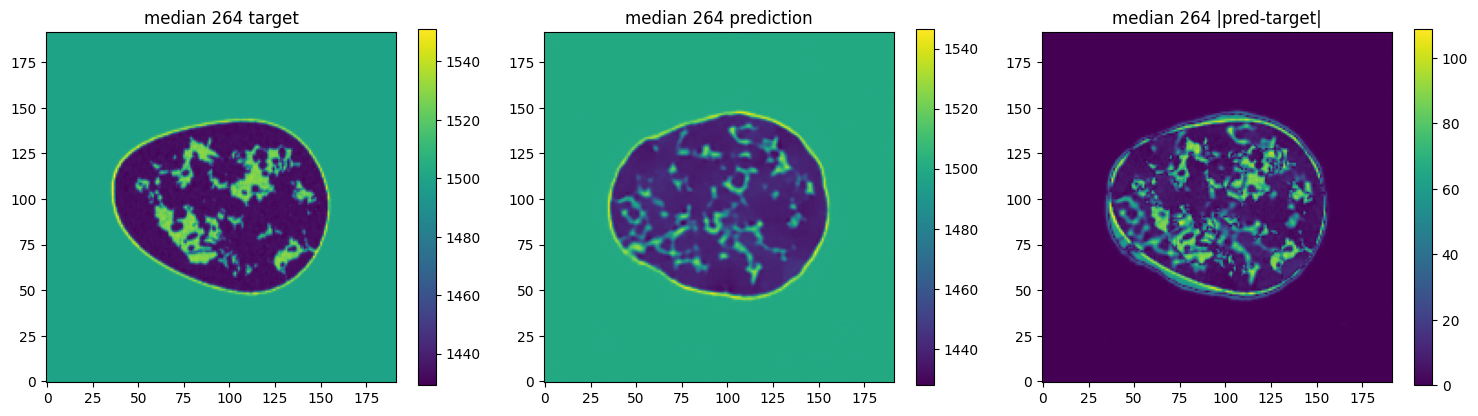

median test example: 302


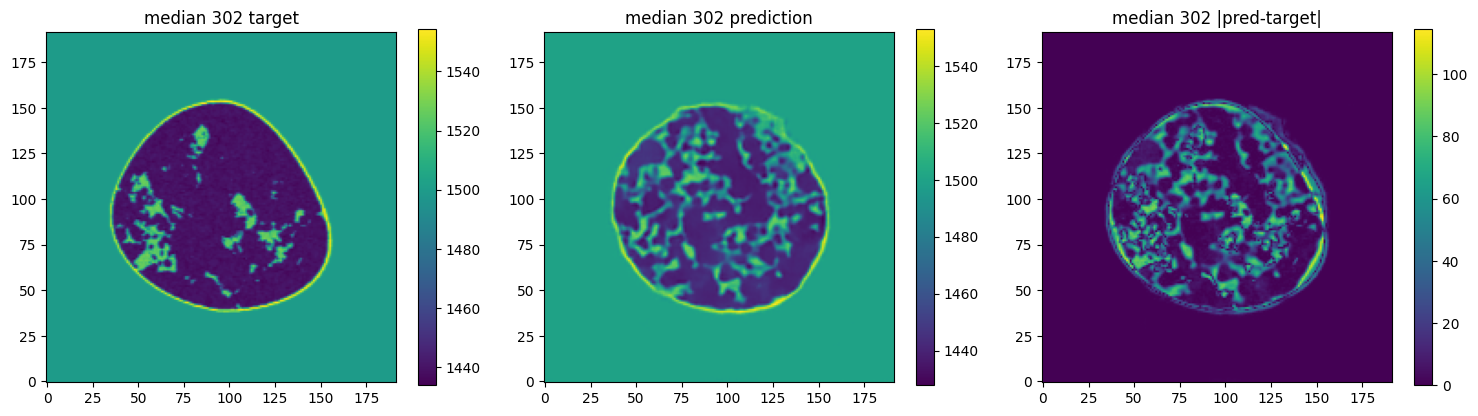

median test example: 788


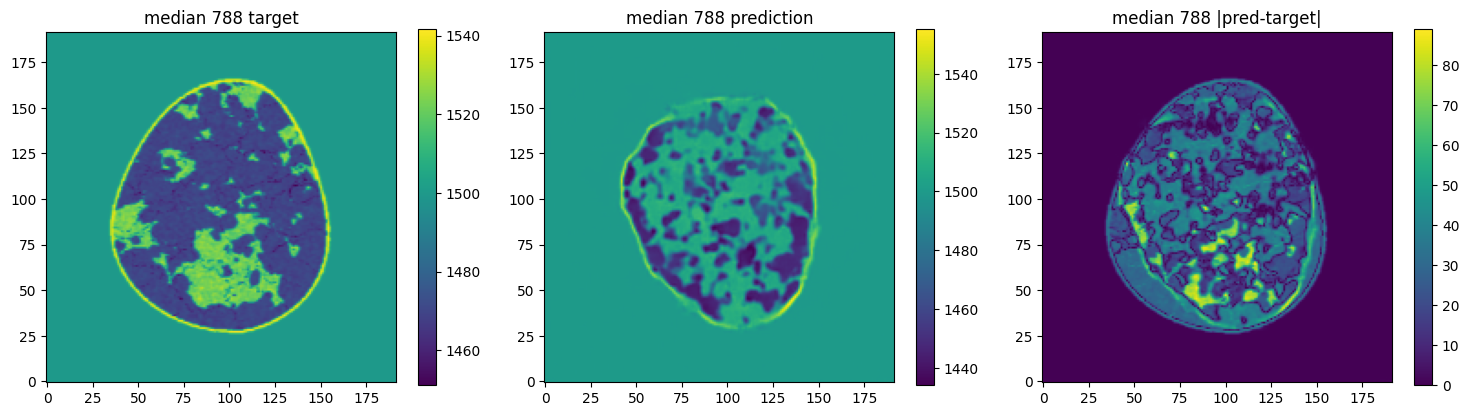

median test example: 322


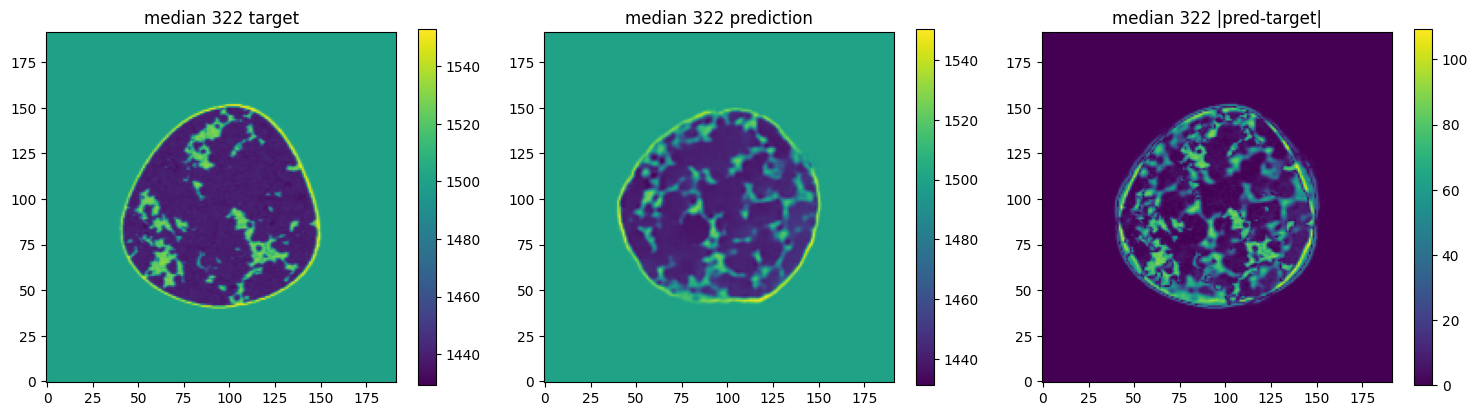

In [17]:
for idx in median_indices:
    print("median test example:", idx)
    show_prediction_case(model, ds_test, idx, device, stats["c_min"], stats["c_max"], title_prefix=f"median {idx}")

best test example: 600


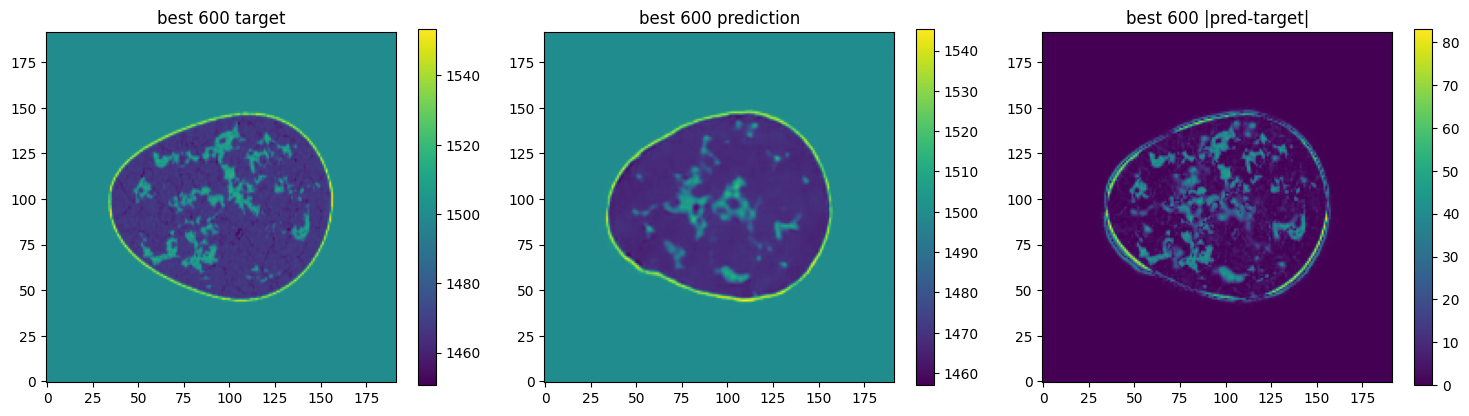

best test example: 350


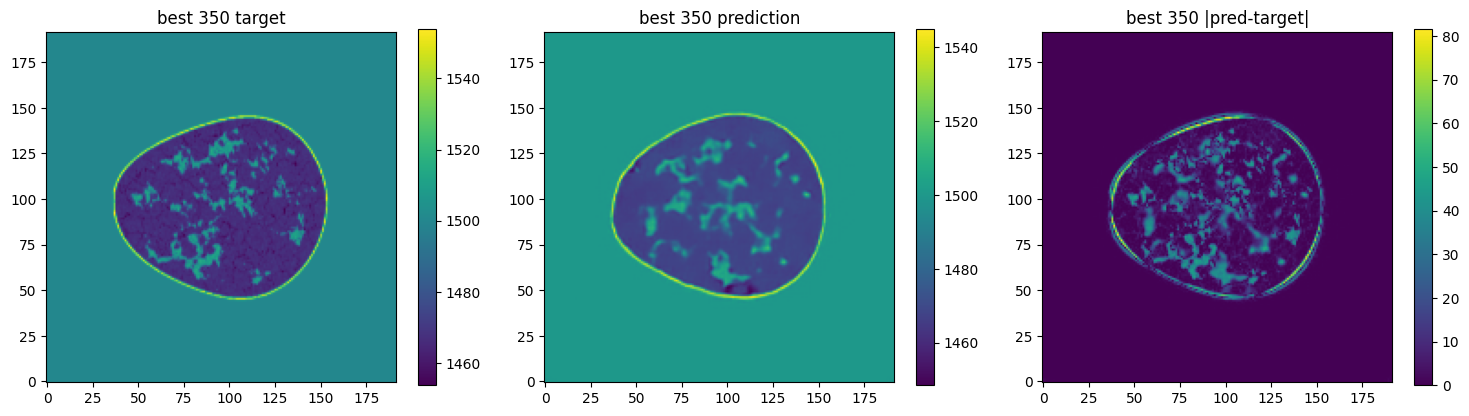

best test example: 630


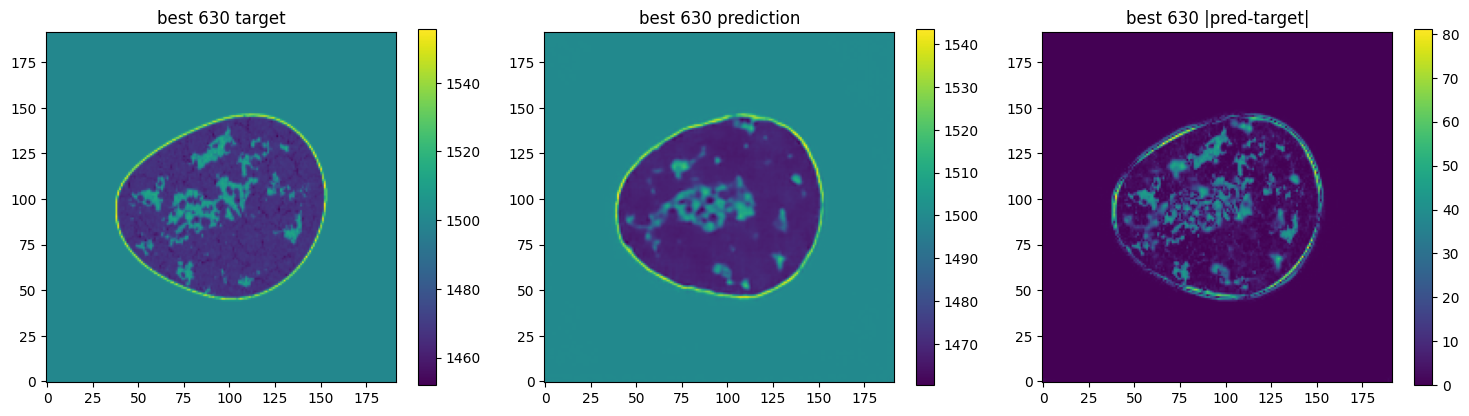

best test example: 152


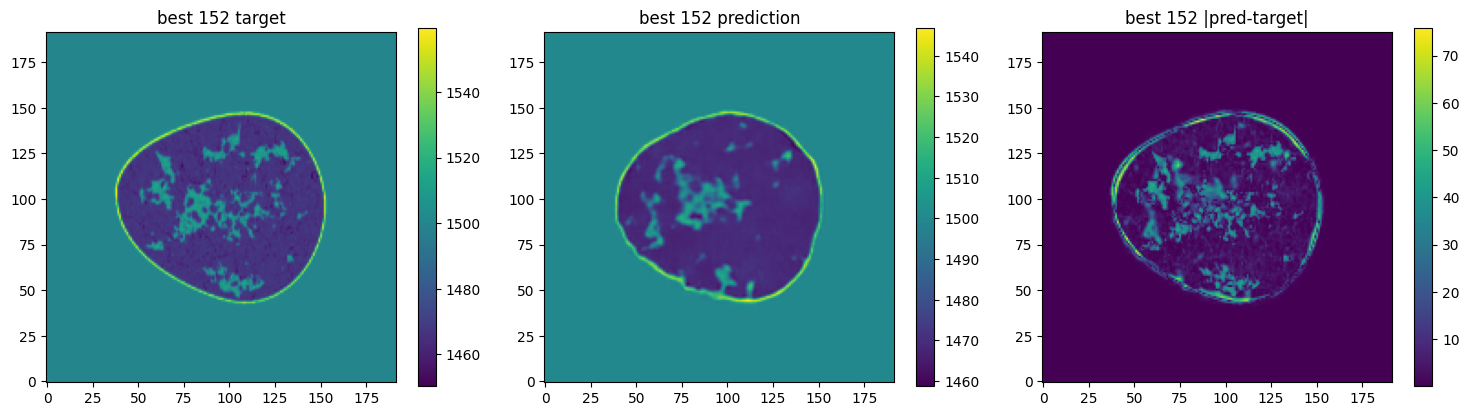

best test example: 609


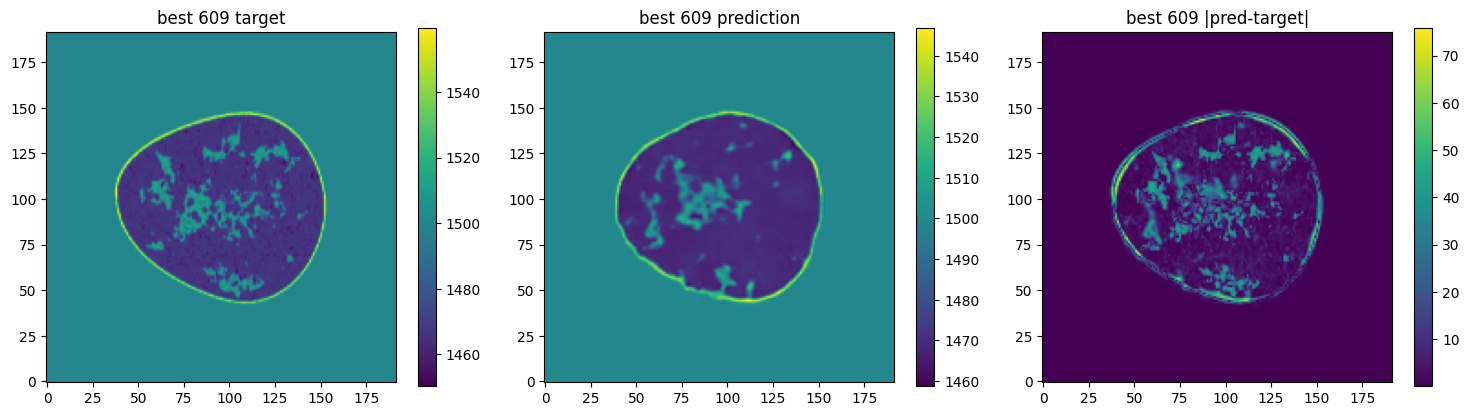

In [18]:
for idx in best_indices:
    print("best test example:", idx)
    show_prediction_case(model, ds_test, idx, device, stats["c_min"], stats["c_max"], title_prefix=f"best {idx}")

In [19]:
def summarize_rows(rows, keys):
    out = {}
    for key in keys:
        vals = [row[key] for row in rows]
        out[f"{key}_mean"] = float(np.mean(vals))
        out[f"{key}_std"] = float(np.std(vals))
    return out

keys_to_compare = ["rmse", "relative_l2", "c_mean", "c_std", "c_min", "c_max"]

worst_summary = summarize_rows(test_sorted[:N_SHOW], keys_to_compare)
median_summary = summarize_rows(median_slice, keys_to_compare)
best_summary = summarize_rows(test_sorted[-N_SHOW:], keys_to_compare)

print("WORST summary")
print(json.dumps(worst_summary, ensure_ascii=False, indent=2))

print("MEDIAN summary")
print(json.dumps(median_summary, ensure_ascii=False, indent=2))

print("BEST summary")
print(json.dumps(best_summary, ensure_ascii=False, indent=2))

WORST summary
{
  "rmse_mean": 31.630690383911134,
  "rmse_std": 1.2825454551723863,
  "relative_l2_mean": 0.021184583008289338,
  "relative_l2_std": 0.0007658700384494171,
  "c_mean_mean": 1492.641796875,
  "c_mean_std": 6.925961960415995,
  "c_std_mean": 25.46170654296875,
  "c_std_std": 3.775973256845703,
  "c_min_mean": 1422.91201171875,
  "c_min_std": 6.209195665266524,
  "c_max_mean": 1565.4882568359376,
  "c_max_std": 15.072220559086787
}
MEDIAN summary
{
  "rmse_mean": 19.128881454467773,
  "rmse_std": 0.04413834161161488,
  "relative_l2_mean": 0.012830180861055852,
  "relative_l2_std": 3.85103065856557e-05,
  "c_mean_mean": 1490.762548828125,
  "c_mean_std": 3.214504935486423,
  "c_std_mean": 22.306294441223145,
  "c_std_std": 4.282119981289177,
  "c_min_mean": 1436.58701171875,
  "c_min_std": 8.219246958948583,
  "c_max_mean": 1551.6791015625,
  "c_max_std": 5.522838163111713
}
BEST summary
{
  "rmse_mean": 8.955140113830566,
  "rmse_std": 0.22968264407584693,
  "relative_l2_

In [20]:
RUN_NAME = "test_case_analysis_v1"
OUT_DIR = Path("/workspace/reference_points") / RUN_NAME
OUT_DIR.mkdir(parents=True, exist_ok=True)

with open(OUT_DIR / "test_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

with open(OUT_DIR / "worst_summary.json", "w", encoding="utf-8") as f:
    json.dump(worst_summary, f, ensure_ascii=False, indent=2)

with open(OUT_DIR / "median_summary.json", "w", encoding="utf-8") as f:
    json.dump(median_summary, f, ensure_ascii=False, indent=2)

with open(OUT_DIR / "best_summary.json", "w", encoding="utf-8") as f:
    json.dump(best_summary, f, ensure_ascii=False, indent=2)

with open(OUT_DIR / "test_metrics_full.json", "w", encoding="utf-8") as f:
    json.dump(test_metrics_list, f, ensure_ascii=False, indent=2)

analysis_config = {
    "run_name": RUN_NAME,
    "checkpoint": str(CKPT_PATH),
    "num_test_examples": len(test_files),
    "n_show": N_SHOW,
    "worst_indices": worst_indices,
    "median_indices": median_indices,
    "best_indices": best_indices,
}

with open(OUT_DIR / "analysis_config.json", "w", encoding="utf-8") as f:
    json.dump(analysis_config, f, ensure_ascii=False, indent=2)

print("saved analysis to:", OUT_DIR)

saved analysis to: /workspace/reference_points/test_case_analysis_v1


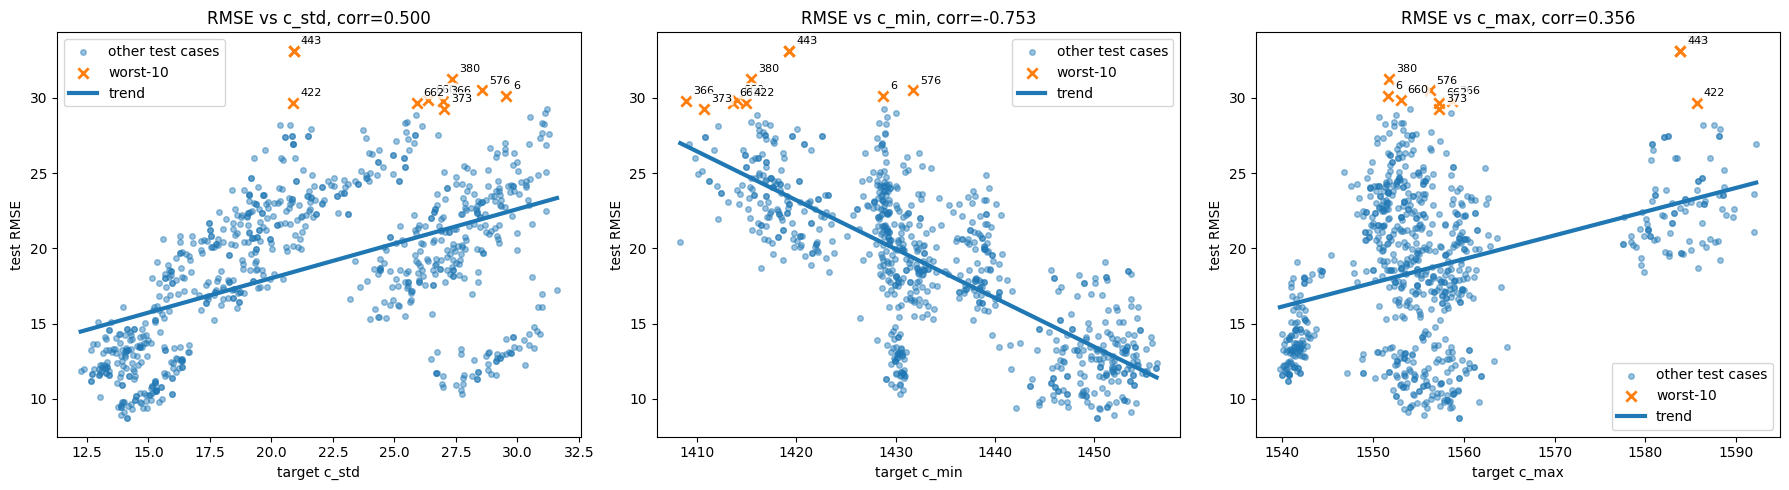

Worst-10 cases:
idx= 109 | rmse=33.1320 | c_std=20.9161 | c_min=1419.3081 | c_max=1583.8378
idx= 443 | rmse=33.1320 | c_std=20.9161 | c_min=1419.3081 | c_max=1583.8378
idx= 380 | rmse=31.2831 | c_std=27.3569 | c_min=1415.4835 | c_max=1551.8240
idx= 576 | rmse=30.4916 | c_std=28.5697 | c_min=1431.7303 | c_max=1556.2554
idx=   6 | rmse=30.1147 | c_std=29.5498 | c_min=1428.7300 | c_max=1551.6864
idx= 660 | rmse=29.8890 | c_std=26.3831 | c_min=1414.0082 | c_max=1553.0396
idx= 366 | rmse=29.7644 | c_std=26.9860 | c_min=1408.8816 | c_max=1558.7262
idx= 662 | rmse=29.6872 | c_std=25.9071 | c_min=1413.5972 | c_max=1557.2545
idx= 422 | rmse=29.6502 | c_std=20.9006 | c_min=1414.9685 | c_max=1585.6278
idx= 373 | rmse=29.2831 | c_std=27.0162 | c_min=1410.7146 | c_max=1557.3235


In [23]:
import numpy as np
import matplotlib.pyplot as plt

rmse = np.array([row["rmse"] for row in test_metrics_list], dtype=np.float32)
c_std = np.array([row["c_std"] for row in test_metrics_list], dtype=np.float32)
c_min = np.array([row["c_min"] for row in test_metrics_list], dtype=np.float32)
c_max = np.array([row["c_max"] for row in test_metrics_list], dtype=np.float32)
idxs = np.array([row["index"] for row in test_metrics_list], dtype=np.int32)

def corr(a, b):
    return float(np.corrcoef(a, b)[0, 1])

def fit_line(x, y):
    k, b = np.polyfit(x, y, 1)
    xx = np.linspace(float(x.min()), float(x.max()), 200)
    yy = k * xx + b
    return xx, yy

worst_sorted = sorted(test_metrics_list, key=lambda x: x["rmse"], reverse=True)
worst10 = worst_sorted[:10]
worst10_idx = {row["index"] for row in worst10}

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

for a, x, name in [
    (ax[0], c_std, "c_std"),
    (ax[1], c_min, "c_min"),
    (ax[2], c_max, "c_max"),
]:
    mask_worst = np.isin(idxs, list(worst10_idx))
    mask_rest = ~mask_worst

    a.scatter(
        x[mask_rest], rmse[mask_rest],
        s=16, alpha=0.45, label="other test cases"
    )

    a.scatter(
        x[mask_worst], rmse[mask_worst],
        s=55, marker="x", linewidths=2, label="worst-10"
    )

    xx, yy = fit_line(x, rmse)
    a.plot(xx, yy, linewidth=3, label="trend")

    for row in worst10:
        i = row["index"]
        pos = np.where(idxs == i)[0][0]
        a.annotate(
            str(i),
            (x[pos], rmse[pos]),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=8,
            bbox=dict(boxstyle="round,pad=0.15", fc="white", alpha=0.8, ec="none"),
        )

    a.set_xlabel(f"target {name}")
    a.set_ylabel("test RMSE")
    a.set_title(f"RMSE vs {name}, corr={corr(rmse, x):.3f}")
    a.legend()

plt.tight_layout()
plt.show()

print("Worst-10 cases:")
for row in worst10:
    print(
        f'idx={row["index"]:4d} | rmse={row["rmse"]:.4f} | '
        f'c_std={row["c_std"]:.4f} | c_min={row["c_min"]:.4f} | c_max={row["c_max"]:.4f}'
    )

TRAIN
c_min        | mean=1433.1937 | std=11.9908 | min=1404.1473 | p25=1426.6165 | median=1430.5615 | p75=1441.1305 | max=1457.9127
c_max        | mean=1556.9468 | std=12.1221 | min=1539.1849 | p25=1550.9177 | median=1554.5787 | p75=1559.0156 | max=1598.3442
c_mean       | mean=1492.0239 | std=5.5158 | min=1477.7542 | p25=1487.3081 | median=1493.6553 | p75=1495.7039 | max=1501.4810
c_std        | mean=21.6021 | std=5.6258 | min=12.0684 | p25=16.4008 | median=20.7406 | p75=26.9910 | max=31.7576

TEST
c_min        | mean=1433.7333 | std=11.9360 | min=1408.3344 | p25=1428.0961 | median=1431.0083 | p75=1444.2938 | max=1456.2520
c_max        | mean=1556.5425 | std=11.6322 | min=1539.7593 | p25=1551.1802 | median=1554.5017 | p75=1558.7532 | max=1592.1995
c_mean       | mean=1491.8999 | std=5.4279 | min=1477.8887 | p25=1487.2091 | median=1493.6115 | p75=1495.6409 | max=1501.1274
c_std        | mean=21.5668 | std=5.6208 | min=12.2525 | p25=16.2465 | median=20.8503 | p75=26.9108 | max=31.6108


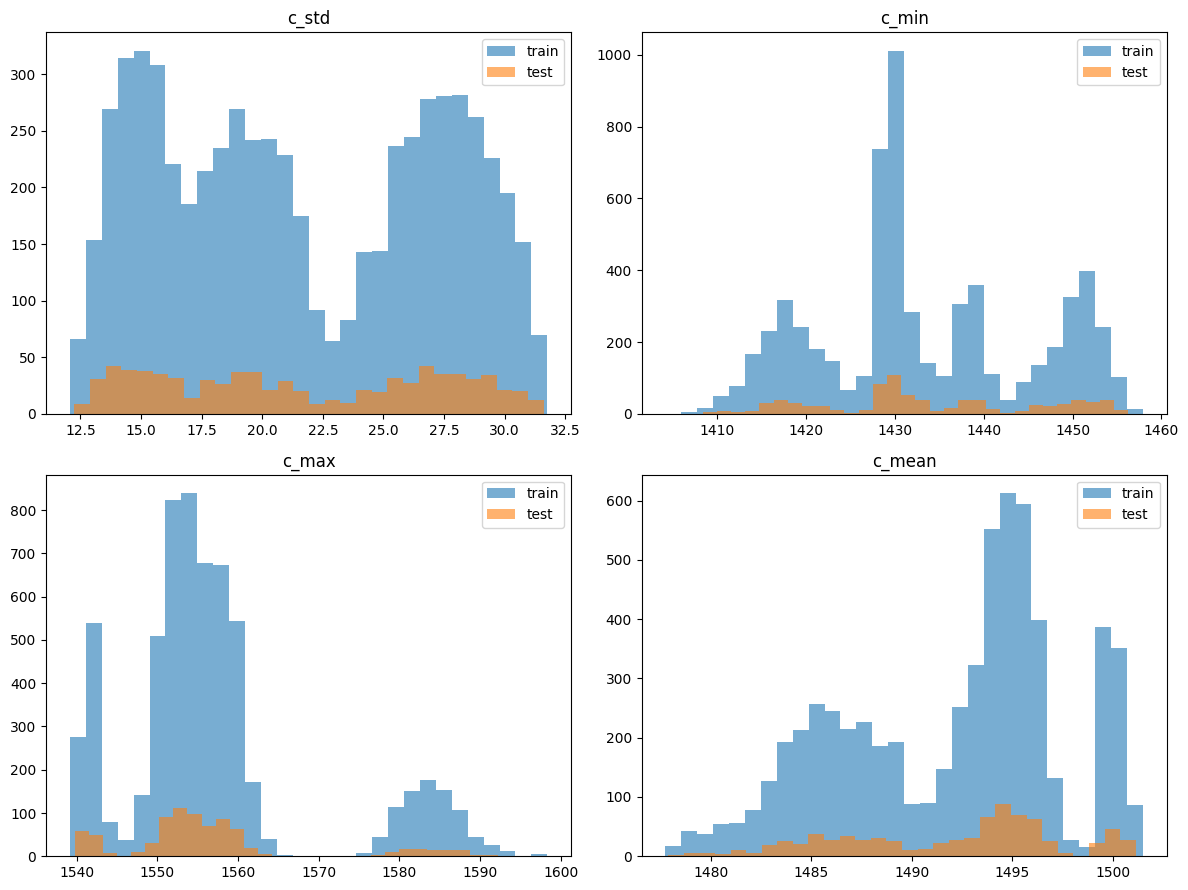

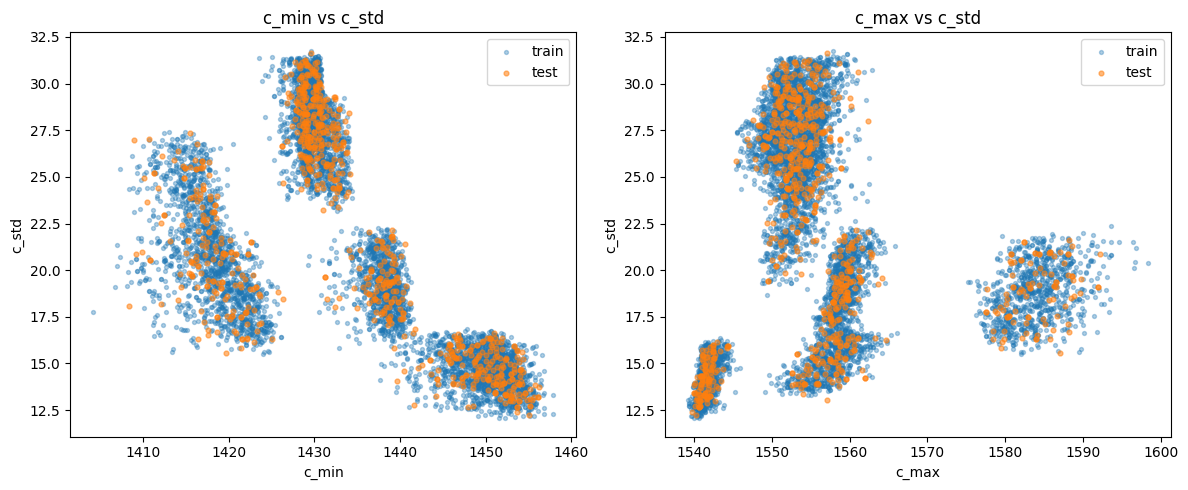

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

train_files = sorted((OUT_ROOT / "train").glob("*.npz"))
test_files = sorted((OUT_ROOT / "test").glob("*.npz"))

def collect_target_stats(paths):
    rows = []
    for i, p in enumerate(paths):
        d = np.load(p)
        c = d["c"].astype(np.float32)
        rows.append({
            "index": i,
            "path": str(p),
            "c_min": float(c.min()),
            "c_max": float(c.max()),
            "c_mean": float(c.mean()),
            "c_std": float(c.std()),
        })
    return rows

train_target_stats = collect_target_stats(train_files)
test_target_stats  = collect_target_stats(test_files)

def arr(rows, key):
    return np.array([r[key] for r in rows], dtype=np.float32)

train_cmin  = arr(train_target_stats, "c_min")
train_cmax  = arr(train_target_stats, "c_max")
train_cmean = arr(train_target_stats, "c_mean")
train_cstd  = arr(train_target_stats, "c_std")

test_cmin   = arr(test_target_stats, "c_min")
test_cmax   = arr(test_target_stats, "c_max")
test_cmean  = arr(test_target_stats, "c_mean")
test_cstd   = arr(test_target_stats, "c_std")

def summarize(name, x):
    print(
        f"{name:12s} | "
        f"mean={x.mean():.4f} | std={x.std():.4f} | "
        f"min={x.min():.4f} | p25={np.percentile(x,25):.4f} | "
        f"median={np.median(x):.4f} | p75={np.percentile(x,75):.4f} | max={x.max():.4f}"
    )

print("TRAIN")
summarize("c_min", train_cmin)
summarize("c_max", train_cmax)
summarize("c_mean", train_cmean)
summarize("c_std", train_cstd)

print("\nTEST")
summarize("c_min", test_cmin)
summarize("c_max", test_cmax)
summarize("c_mean", test_cmean)
summarize("c_std", test_cstd)

fig, ax = plt.subplots(2, 2, figsize=(12, 9))

ax[0, 0].hist(train_cstd, bins=30, alpha=0.6, label="train")
ax[0, 0].hist(test_cstd, bins=30, alpha=0.6, label="test")
ax[0, 0].set_title("c_std")
ax[0, 0].legend()

ax[0, 1].hist(train_cmin, bins=30, alpha=0.6, label="train")
ax[0, 1].hist(test_cmin, bins=30, alpha=0.6, label="test")
ax[0, 1].set_title("c_min")
ax[0, 1].legend()

ax[1, 0].hist(train_cmax, bins=30, alpha=0.6, label="train")
ax[1, 0].hist(test_cmax, bins=30, alpha=0.6, label="test")
ax[1, 0].set_title("c_max")
ax[1, 0].legend()

ax[1, 1].hist(train_cmean, bins=30, alpha=0.6, label="train")
ax[1, 1].hist(test_cmean, bins=30, alpha=0.6, label="test")
ax[1, 1].set_title("c_mean")
ax[1, 1].legend()

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].scatter(train_cmin, train_cstd, s=8, alpha=0.35, label="train")
ax[0].scatter(test_cmin, test_cstd, s=12, alpha=0.55, label="test")
ax[0].set_xlabel("c_min")
ax[0].set_ylabel("c_std")
ax[0].set_title("c_min vs c_std")
ax[0].legend()

ax[1].scatter(train_cmax, train_cstd, s=8, alpha=0.35, label="train")
ax[1].scatter(test_cmax, test_cstd, s=12, alpha=0.55, label="test")
ax[1].set_xlabel("c_max")
ax[1].set_ylabel("c_std")
ax[1].set_title("c_max vs c_std")
ax[1].legend()

plt.tight_layout()
plt.show()

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

train_files = sorted((OUT_ROOT / "train").glob("*.npz"))
test_files  = sorted((OUT_ROOT / "test").glob("*.npz"))

print("train:", len(train_files))
print("test :", len(test_files))

def preprocess_M_from_file(path, M_hom_complex, mask_half_width=2):
    d = np.load(path)

    x_raw = d["x"].astype(np.float32)
    src_idx = d["source_ring_idx"].astype(np.int64)

    M = x_raw[0] + 1j * x_raw[1]
    M = M - M_hom_complex

    if mask_half_width > 0:
        M = mask_self_receivers(M, src_idx, half_width=mask_half_width)

    x = np.stack([M.real, M.imag], axis=0).astype(np.float32)

    x_scale = float(np.percentile(np.abs(x), 99.5))
    if x_scale < 1e-8:
        x_scale = 1.0
    x = x / x_scale

    M_norm = x[0] + 1j * x[1]
    return M_norm

def measurement_stats(M):
    amp = np.abs(M)
    phase = np.angle(M)

    return {
        "amp_mean": float(amp.mean()),
        "amp_std": float(amp.std()),
        "amp_max": float(amp.max()),
        "amp_p95": float(np.percentile(amp, 95)),
        "real_mean": float(M.real.mean()),
        "real_std": float(M.real.std()),
        "imag_mean": float(M.imag.mean()),
        "imag_std": float(M.imag.std()),
        "phase_mean": float(phase.mean()),
        "phase_std": float(phase.std()),
    }

train_meas_stats = [measurement_stats(preprocess_M_from_file(p, M_hom_complex, 2)) for p in train_files]
test_meas_stats  = [measurement_stats(preprocess_M_from_file(p, M_hom_complex, 2)) for p in test_files]

print("done:", len(train_meas_stats), len(test_meas_stats))

train: 6200
test : 800
done: 6200 800


In [27]:
def arr(rows, key):
    return np.array([r[key] for r in rows], dtype=np.float32)

keys = [
    "amp_mean", "amp_std", "amp_max", "amp_p95",
    "real_mean", "real_std", "imag_mean", "imag_std",
    "phase_mean", "phase_std",
]

for k in keys:
    tr = arr(train_meas_stats, k)
    te = arr(test_meas_stats, k)
    print(
        f"{k:12s} | "
        f"train mean={tr.mean():.4f}, std={tr.std():.4f} || "
        f"test mean={te.mean():.4f}, std={te.std():.4f}"
    )

amp_mean     | train mean=0.3796, std=0.0587 || test mean=0.3806, std=0.0594
amp_std      | train mean=0.2823, std=0.0348 || test mean=0.2837, std=0.0350
amp_max      | train mean=1.3062, std=0.1409 || test mean=1.3047, std=0.1396
amp_p95      | train mean=0.8935, std=0.0514 || test mean=0.8950, std=0.0515
real_mean    | train mean=0.0161, std=0.0105 || test mean=0.0164, std=0.0111
real_std     | train mean=0.3352, std=0.0431 || test mean=0.3363, std=0.0439
imag_mean    | train mean=0.0017, std=0.0066 || test mean=0.0014, std=0.0063
imag_std     | train mean=0.3346, std=0.0434 || test mean=0.3358, std=0.0437
phase_mean   | train mean=-0.0104, std=0.0301 || test mean=-0.0090, std=0.0297
phase_std    | train mean=1.7647, std=0.0135 || test mean=1.7647, std=0.0146


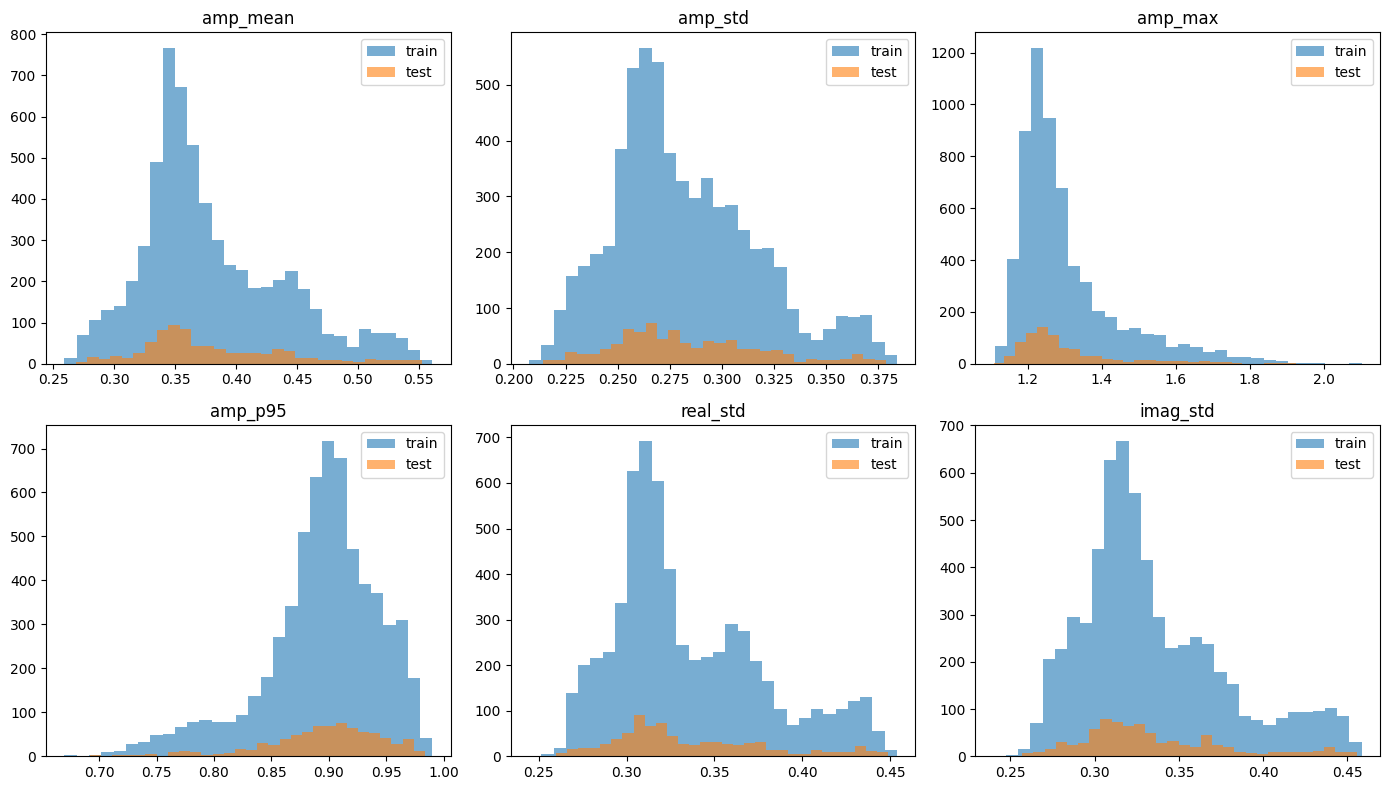

In [29]:
fig, ax = plt.subplots(2, 3, figsize=(14, 8))

plot_keys = ["amp_mean", "amp_std", "amp_max", "amp_p95", "real_std", "imag_std"]

for a, k in zip(ax.ravel(), plot_keys):
    tr = arr(train_meas_stats, k)
    te = arr(test_meas_stats, k)

    a.hist(tr, bins=30, alpha=0.6, label="train")
    a.hist(te, bins=30, alpha=0.6, label="test")
    a.set_title(k)
    a.legend()

plt.tight_layout()
plt.show()

In [32]:
%pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 95.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn] [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


In [33]:
from sklearn.decomposition import PCA

rng = np.random.default_rng(42)

N_TRAIN_SUB = min(1500, len(train_files))
train_sub_idx = rng.choice(len(train_files), size=N_TRAIN_SUB, replace=False)
train_sub_files = [train_files[i] for i in sorted(train_sub_idx)]

X_train = []
for p in train_sub_files:
    M = preprocess_M_from_file(p, M_hom_complex, 2)
    x = np.stack([M.real, M.imag], axis=0).astype(np.float32)
    X_train.append(x.reshape(-1))

X_test = []
for p in test_files:
    M = preprocess_M_from_file(p, M_hom_complex, 2)
    x = np.stack([M.real, M.imag], axis=0).astype(np.float32)
    X_test.append(x.reshape(-1))

X_train = np.stack(X_train, axis=0)
X_test = np.stack(X_test, axis=0)

X_all = np.concatenate([X_train, X_test], axis=0)
y_all = np.array(["train"] * len(X_train) + ["test"] * len(X_test))

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("X_all  :", X_all.shape)

X_train: (1500, 8192)
X_test : (800, 8192)
X_all  : (2300, 8192)


explained variance ratio: [0.24515279 0.10529298]
total explained: 0.35044578


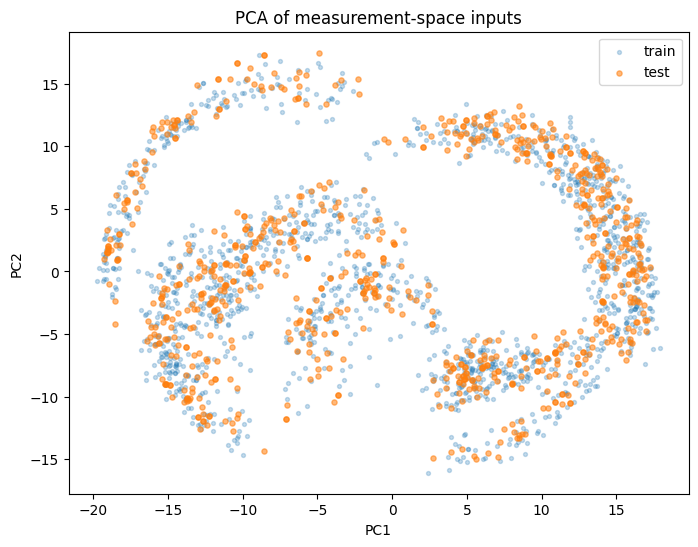

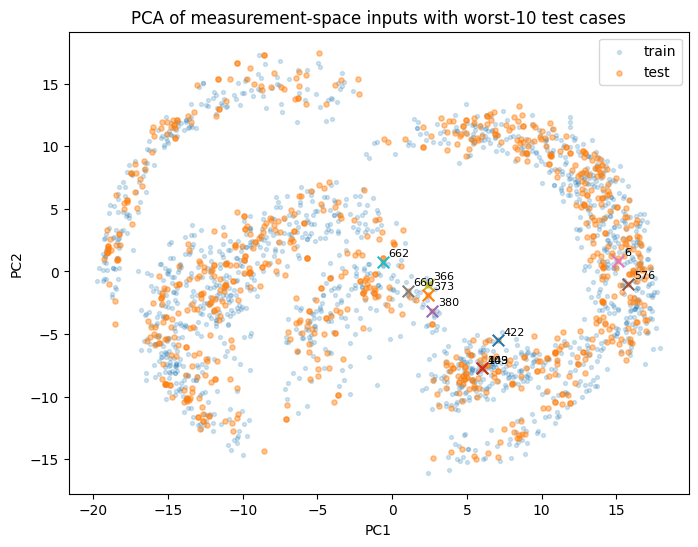

In [36]:
pca = PCA(n_components=2, random_state=42)
Z = pca.fit_transform(X_all)

print("explained variance ratio:", pca.explained_variance_ratio_)
print("total explained:", pca.explained_variance_ratio_.sum())

mask_train = (y_all == "train")
mask_test = (y_all == "test")

plt.figure(figsize=(8, 6))
plt.scatter(Z[mask_train, 0], Z[mask_train, 1], s=8, alpha=0.25, label="train")
plt.scatter(Z[mask_test, 0], Z[mask_test, 1], s=14, alpha=0.55, label="test")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of measurement-space inputs")
plt.legend()
plt.show()

test_sorted = sorted(test_metrics_list, key=lambda x: x["rmse"], reverse=True)
worst10_idx = [row["index"] for row in test_sorted[:10]]

Z_test = Z[len(X_train):]

plt.figure(figsize=(8, 6))
plt.scatter(Z[mask_train, 0], Z[mask_train, 1], s=8, alpha=0.20, label="train")
plt.scatter(Z_test[:, 0], Z_test[:, 1], s=14, alpha=0.45, label="test")

for idx in worst10_idx:
    plt.scatter(Z_test[idx, 0], Z_test[idx, 1], s=70, marker="x")
    plt.annotate(str(idx), (Z_test[idx, 0], Z_test[idx, 1]), xytext=(4, 4), textcoords="offset points", fontsize=8)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of measurement-space inputs with worst-10 test cases")
plt.legend()
plt.show()